<a href="https://colab.research.google.com/github/TAUforPython/NeuralODE/blob/main/NeuralODE_Temporal_Neural_Operator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Temporal Neural Operator (TNO) for Time Series Prediction

A **Temporal Neural Operator (TNO)** is a type of neural network designed to learn mappings between infinite-dimensional function spaces. Unlike traditional neural networks that learn mappings between finite-dimensional Euclidean spaces, operators learn a mapping between entire functions. In the context of time series, this means a TNO can learn a direct mapping from an entire past time series function to an entire future time series function, rather than just learning from discrete points.

### How it Works for Time Series Prediction:

For time series prediction, a TNO typically employs a two-branch architecture, often inspired by **DeepONets** (Deep Operator Networks), but specialized for temporal data:

1.  **Temporal Branch (or History Branch):**
    *   This branch processes the *input history* of the time series (e.g., `X_train` in the notebook). It typically uses recurrent neural networks like LSTMs or GRUs, or other sequence processing architectures, to extract meaningful *temporal features* or a latent representation of the past dynamics. The goal is to condense the entire input sequence into a fixed-size vector that encapsulates the "current state" or trend of the series.

2.  **Trunk Network (or Time Coordinate Branch):**
    *   This branch processes the *query points* (e.g., the future time indices for which we want predictions). Its role is to generate features corresponding to these specific future time steps. In the provided simplified model, this is handled by an `nn.Embedding` layer that learns a unique embedding for each future time step, essentially representing the "positional information" for prediction.

3.  **Combination and Decoding:**
    *   The features extracted from the temporal branch (representing the state based on history) are combined with the features from the trunk network (representing the future time points). A common way to combine these is through an element-wise product (like the Hadamard product), which allows the model to modulate the temporal features based on the specific time point being queried.
    *   Finally, a simple decoder (e.g., a fully connected layer) maps these combined features to the predicted value at that specific future time point. By iterating this process for all desired future time steps, the TNO outputs the entire predicted future time series.

In essence, the TNO learns a generalizable operator that can map any observed past time series to its corresponding future values, effectively learning the underlying dynamic system rather than just a fixed-length input-output relationship.

In [1]:
# -*- coding: utf-8 -*-
"""TNO_1D_Timeseries_Prediction.ipynb
Temporal Neural Operator (TNO) for 1D Time Series Prediction
Based on: https://www.nature.com/articles/s41598-025-16922-5
"""

# Cell 1: Install required packages
!pip install torch -q
#!pip install einops -q


Using device: cuda
--- Generating Synthetic 1-D Time Series Data ---
Generated 2000 valid sequences.
Input shape: torch.Size([1600, 20, 1])
Target shape: torch.Size([1600, 20, 1])
--- Data Generation and Scaling Complete ---
--- Defining Simplified TNO Model ---
--- Model Defined ---
--- Starting Training ---
Epoch [50/3000], Loss: 0.986575
Epoch [100/3000], Loss: 0.971788
Epoch [150/3000], Loss: 0.930149
Epoch [200/3000], Loss: 0.909255
Epoch [250/3000], Loss: 0.895402
Epoch [300/3000], Loss: 0.881889
Epoch [350/3000], Loss: 0.868984
Epoch [400/3000], Loss: 0.856626
Epoch [450/3000], Loss: 0.844286
Epoch [500/3000], Loss: 0.827477
Epoch [550/3000], Loss: 0.819971
Epoch [600/3000], Loss: 0.803425
Epoch [650/3000], Loss: 0.792761
Epoch [700/3000], Loss: 0.783378
Epoch [750/3000], Loss: 0.773829
Epoch [800/3000], Loss: 0.763150
Epoch [850/3000], Loss: 0.754912
Epoch [900/3000], Loss: 0.745882
Epoch [950/3000], Loss: 0.736768
Epoch [1000/3000], Loss: 0.735342
Epoch [1050/3000], Loss: 0.72

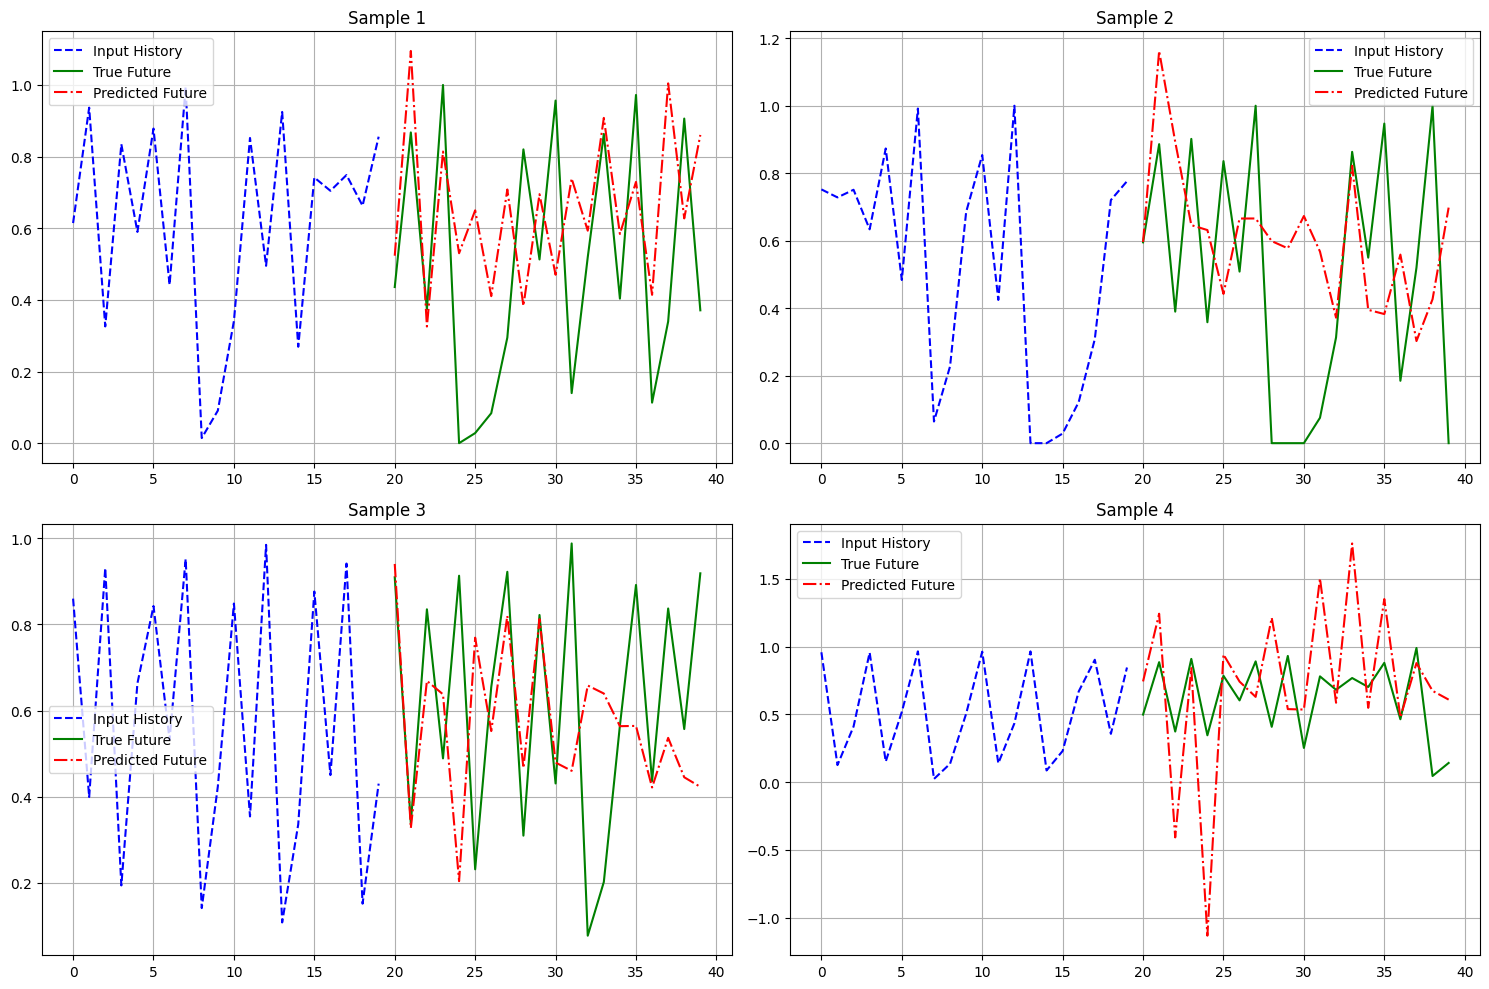

--- Plotting Complete ---


In [ ]:
# --- Google Colab Setup ---
# Ensure you are using a GPU runtime for faster execution if needed.
# Runtime -> Change runtime type -> Hardware accelerator -> GPU

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- 1. Data Generation (Simulated 1-D Time Series) ---
def generate_data(n_samples=1000, seq_len=50, noise_level=0.05):
    """
    Generates synthetic 1-D time series data.
    Inspired by the paper's focus on learning dynamics, we create sequences
    based on a function with some temporal dependency, e.g., a damped oscillator
    or a chaotic system like the logistic map.
    """
    X = [] # Input sequences (e.g., history)
    Y = [] # Target sequences (e.g., future steps)

    for _ in range(n_samples):
        attempts = 0
        max_attempts = 5 # Limit attempts to avoid infinite loop if parameters are problematic
        valid_sequence = False

        while not valid_sequence and attempts < max_attempts:
            # Random initial conditions and parameters for diversity
            r = np.random.uniform(3.5, 4.0) # Logistic map parameter
            x0 = np.random.uniform(0.1, 0.9) # Initial value

            # Generate a longer sequence using the logistic map
            full_seq = []
            x = x0
            sequence_valid = True
            for _ in range(seq_len * 2): # Generate enough for input+target
                x_new = r * x * (1 - x) + np.random.normal(0, noise_level)

                # Add a small epsilon to prevent x from becoming 0 or 1 exactly
                x_new = np.clip(x_new, 1e-10, 1.0 - 1e-10)

                # Check for inf or NaN before appending
                if np.isnan(x_new) or np.isinf(x_new):
                    sequence_valid = False
                    break
                full_seq.append(x_new)
                x = x_new

            if sequence_valid and len(full_seq) == seq_len * 2:
                 # Split into input (history) and target
                input_seq = full_seq[:seq_len]
                target_seq = full_seq[seq_len:]

                # Final check on the assembled sequences
                if not (np.any(np.isnan(input_seq)) or np.any(np.isinf(input_seq)) or
                        np.any(np.isnan(target_seq)) or np.any(np.isinf(target_seq))):
                     X.append(input_seq)
                     Y.append(target_seq)
                     valid_sequence = True
            attempts += 1

        if not valid_sequence:
            print(f"Warning: Could not generate a valid sequence after {max_attempts} attempts for sample {_}. Skipping.")
            continue # Skip adding this sample if all attempts failed

    if len(X) == 0 or len(Y) == 0:
         raise ValueError("No valid sequences could be generated. Adjust parameters or increase max_attempts.")

    return np.array(X), np.array(Y)

print("--- Generating Synthetic 1-D Time Series Data ---")
X_raw, Y_raw = generate_data(n_samples=2000, seq_len=20) # Reduced for demo speed

print(f"Generated {len(X_raw)} valid sequences.")

# --- Corrected Scaler Fitting and Transform ---
# Fit scalers correctly on the 2D representation matching raw data shape
# X_raw is (N, seq_len), so reshaping to (-1, seq_len) would fit one scaler per timestep.
# Instead, fit one scaler for the single 'feature' across all timesteps and samples.
X_reshaped_to_fit_scaler = X_raw.reshape(-1, 1) # Shape: (N * seq_len, 1)
Y_reshaped_to_fit_scaler = Y_raw.reshape(-1, 1) # Shape: (N * seq_len, 1)

scaler_X = StandardScaler()
scaler_Y = StandardScaler()

scaler_X.fit(X_reshaped_to_fit_scaler) # Fit on (N*seq_len, 1)
scaler_Y.fit(Y_reshaped_to_fit_scaler) # Fit on (N*seq_len, 1)

# Transform the original shaped data using the fitted scalers
X_scaled = scaler_X.transform(X_reshaped_to_fit_scaler).reshape(X_raw.shape) # Back to (N, seq_len)
Y_scaled = scaler_Y.transform(Y_reshaped_to_fit_scaler).reshape(Y_raw.shape) # Back to (N, seq_len)

# Convert to PyTorch tensors, adding the channel dimension
X_tensor = torch.FloatTensor(X_scaled).unsqueeze(-1) # Shape: (N, seq_len, 1)
Y_tensor = torch.FloatTensor(Y_scaled).unsqueeze(-1) # Shape: (N, seq_len, 1)

# Simple train/test split
split_idx = int(0.8 * len(X_tensor))
X_train, X_test = X_tensor[:split_idx], X_tensor[split_idx:]
Y_train, Y_test = Y_tensor[:split_idx], Y_tensor[split_idx:]

print(f"Input shape: {X_train.shape}")
print(f"Target shape: {Y_train.shape}")
print("--- Data Generation and Scaling Complete ---")

# --- 2. TNO-Inspired Model Definition (Simplified for 1D) ---
class TemporalBranch(nn.Module):
    """Processes the temporal history (input sequence) using an LSTM."""
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: (batch, seq_len, input_features=1)
        lstm_out, _ = self.lstm(x)
        # Take the last output of the LSTM
        last_output = lstm_out[:, -1, :] # (batch, hidden_size)
        output = self.fc(last_output) # (batch, output_size)
        return output

class TrunkNetwork(nn.Module):
    """Processes the temporal query points (time indices)."""
    def __init__(self, n_time_points, output_size):
        super().__init__()
        # Create embeddings for each time step in the target sequence
        self.time_embedding = nn.Embedding(n_time_points, output_size)

    def forward(self, x):
        # x is a dummy input here, just the indices [0, 1, ..., K-1]
        batch_size, seq_len, _ = x.shape
        time_indices = torch.arange(seq_len, dtype=torch.long, device=x.device).expand(batch_size, -1)
        # Embed time indices
        time_emb = self.time_embedding(time_indices) # (batch, seq_len, output_size)
        return time_emb

class SimplifiedTNO(nn.Module):
    """
    A simplified model inspired by the Temporal Neural Operator (TNO) architecture.
    It incorporates a temporal branch (like TNO's t-branch) to process the history,
    and a trunk to process time coordinates, then combines them.
    """
    def __init__(self, input_size=1, hidden_size=64, trunk_size=64, output_size=20):
        super().__init__()
        self.temporal_branch = TemporalBranch(input_size, hidden_size, trunk_size)
        self.trunk_network = TrunkNetwork(output_size, trunk_size) # trunk_size matches latent dim
        self.decoder = nn.Linear(trunk_size, 1) # Map latent to single output value
        self.output_size = output_size

    def forward(self, x_history):
        # x_history shape: (batch, seq_len_history, input_features=1)

        # Process history through temporal branch
        # Output: (batch, trunk_size)
        temporal_features = self.temporal_branch(x_history)

        # Repeat temporal features for each target time step
        # Shape becomes (batch, output_size, trunk_size)
        repeated_temporal = temporal_features.unsqueeze(1).repeat(1, self.output_size, 1)

        # Process time coordinates through trunk
        # Dummy input for trunk - just needs shape info
        dummy_input_for_trunk = torch.zeros_like(x_history[:, :self.output_size, :])
        trunk_features = self.trunk_network(dummy_input_for_trunk) # (batch, output_size, trunk_size)

        # Combine features (e.g., Hadamard product as in TNO)
        combined_features = repeated_temporal * trunk_features # (batch, output_size, trunk_size)

        # Decode to final output
        output = self.decoder(combined_features).squeeze(-1) # (batch, output_size)

        return output

print("--- Defining Simplified TNO Model ---")
model = SimplifiedTNO(input_size=1, hidden_size=64, trunk_size=64, output_size=Y_train.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
print("--- Model Defined ---")

# --- 3. Training Loop ---
print("--- Starting Training ---")
num_epochs = 3000 # Increased epochs for better convergence on this toy problem
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    outputs = model(X_train.to(device))
    loss = criterion(outputs, Y_train.to(device).squeeze(-1)) # Remove channel dim for loss

    loss.backward()
    optimizer.step()

    if (epoch+1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}')

print("--- Training Complete ---")

# --- 4. Evaluation and Visualization ---
print("--- Evaluating Model ---")
model.eval()
with torch.no_grad():
    test_outputs = model(X_test.to(device))
    test_loss = criterion(test_outputs, Y_test.to(device).squeeze(-1))
    # Inverse transform predictions and targets for interpretable metrics
    test_outputs_np = scaler_Y.inverse_transform(test_outputs.cpu().numpy().reshape(-1, 1)).reshape(test_outputs.shape) # Reshape for scaler
    Y_test_np = scaler_Y.inverse_transform(Y_test.squeeze(-1).cpu().numpy().reshape(-1, 1)).reshape(Y_test.squeeze(-1).shape) # Reshape for scaler

    mse = mean_squared_error(Y_test_np.flatten(), test_outputs_np.flatten()) # Flatten for overall metrics
    mae = mean_absolute_error(Y_test_np.flatten(), test_outputs_np.flatten())

print(f'Test MSE: {mse:.6f}')
print(f'Test MAE: {mae:.6f}')
print("--- Evaluation Complete ---")

# Visualization
print("--- Plotting Predictions ---")
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i in range(min(4, len(X_test))):
    # Inverse transform for plotting - FIX: Reshape correctly for scaler
    # X_test[i] has shape (seq_len, 1). We need to pass (n_samples, n_features) to scaler.
    # So, reshape (seq_len, 1) -> (seq_len * 1, 1) -> pass to scaler -> reshape back to (seq_len, 1) -> ravel to (seq_len,)
    x_plot = scaler_X.inverse_transform(X_test[i].cpu().numpy().reshape(-1, 1)).reshape(X_test[i].shape).ravel()
    y_true_plot = Y_test_np[i]
    y_pred_plot = test_outputs_np[i]

    axes[i].plot(range(len(x_plot)), x_plot, label='Input History', linestyle='--', color='blue')
    axes[i].plot(range(len(x_plot), len(x_plot) + len(y_true_plot)), y_true_plot, label='True Future', color='green')
    axes[i].plot(range(len(x_plot), len(x_plot) + len(y_pred_plot)), y_pred_plot, label='Predicted Future', color='red', linestyle='-.')
    axes[i].set_title(f'Sample {i+1}')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()
print("--- Plotting Complete ---")


# Four different samples

Using device: cuda
--- Generating New Synthetic 1-D Time Series Data ---
Train dataset shape: (1600, 50), (1600, 50)
Test dataset shape: (400, 50), (400, 50)
Input shape: torch.Size([1600, 50, 1])
Target shape: torch.Size([1600, 50, 1])
--- Data Generation, Scaling, and Tensor Conversion Complete ---
--- Defining Simplified TNO Model ---
--- Model Defined ---
--- Starting Training ---
Epoch [50/3000], Loss: 0.752929
Epoch [100/3000], Loss: 0.598967
Epoch [150/3000], Loss: 0.530723
Epoch [200/3000], Loss: 0.472393
Epoch [250/3000], Loss: 0.399992
Epoch [300/3000], Loss: 0.310238
Epoch [350/3000], Loss: 0.261850
Epoch [400/3000], Loss: 0.227656
Epoch [450/3000], Loss: 0.199356
Epoch [500/3000], Loss: 0.176957
Epoch [550/3000], Loss: 0.163586
Epoch [600/3000], Loss: 0.144931
Epoch [650/3000], Loss: 0.139705
Epoch [700/3000], Loss: 0.126578
Epoch [750/3000], Loss: 0.121720
Epoch [800/3000], Loss: 0.108426
Epoch [850/3000], Loss: 0.105169
Epoch [900/3000], Loss: 0.132399
Epoch [950/3000], L

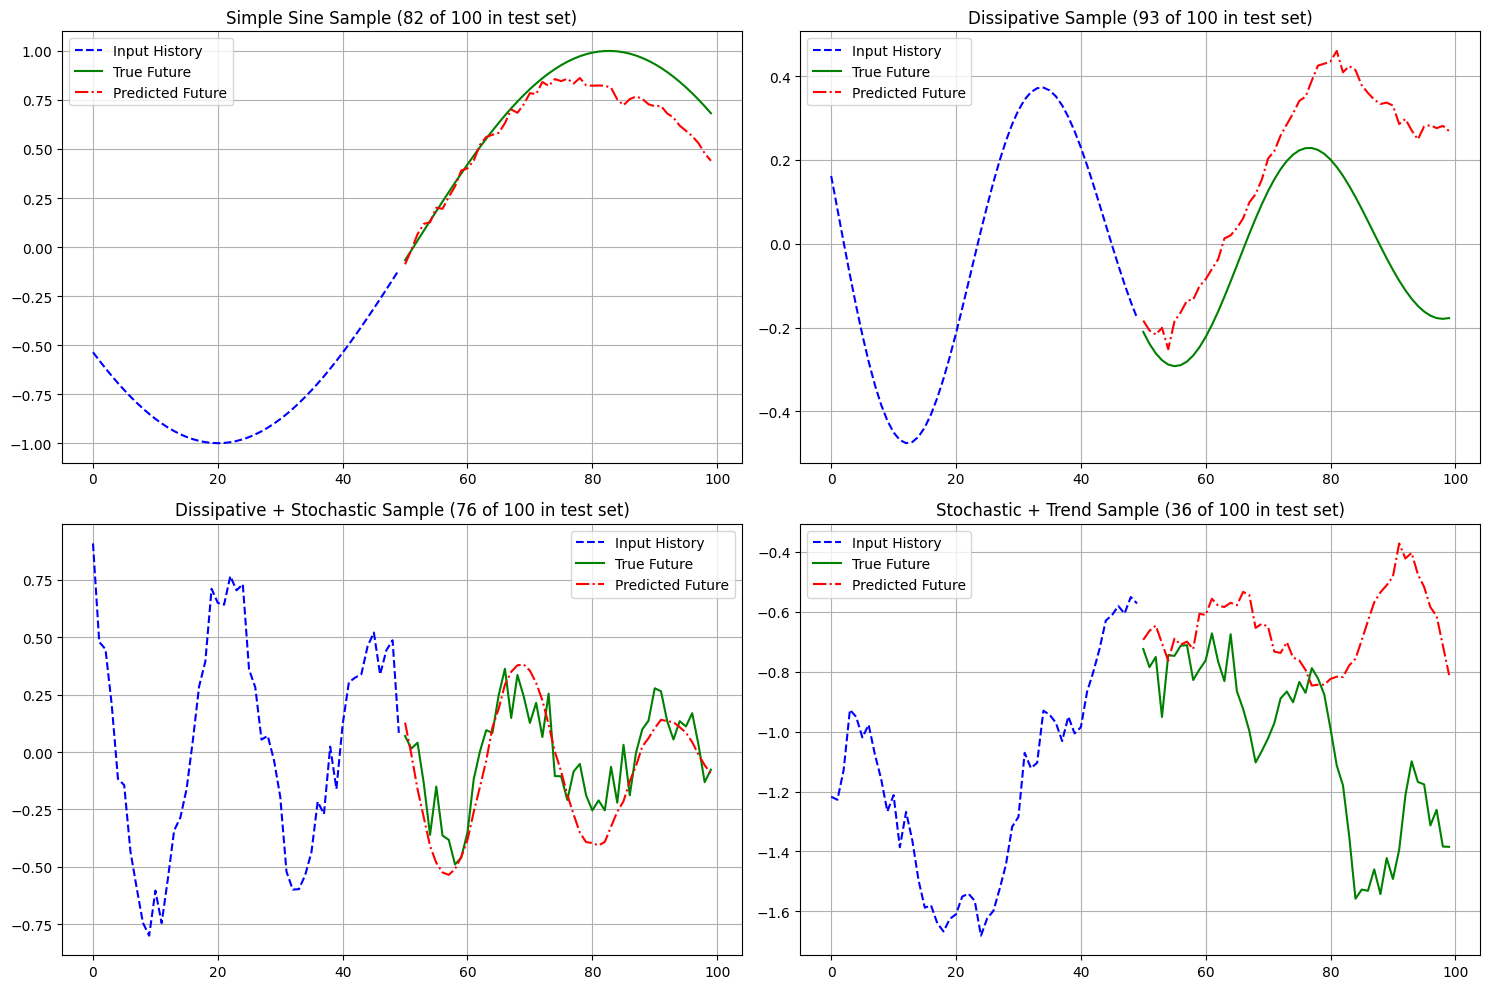

--- Plotting Complete ---


In [2]:
# --- Google Colab Setup ---
# Ensure you are using a GPU runtime for faster execution if needed.
# Runtime -> Change runtime type -> Hardware accelerator -> GPU

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- 1. Data Generation (New 4 Types of Synthetic 1-D Time Series) ---
def generate_simple_sine(n_samples=500, seq_len=50):
    """Generates simple sine waves with random frequency and phase."""
    X = []
    Y = []
    for _ in range(n_samples):
        freq = np.random.uniform(0.05, 0.2)
        phase = np.random.uniform(0, 2*np.pi)
        start_idx = np.random.randint(0, 100)

        full_seq = np.sin(freq * np.arange(start_idx, start_idx + seq_len * 2) + phase)
        input_seq = full_seq[:seq_len]
        target_seq = full_seq[seq_len:]

        X.append(input_seq)
        Y.append(target_seq)
    return np.array(X), np.array(Y)

def generate_dissipative(n_samples=500, seq_len=50):
    """Generates dissipative system-like data, e.g., damped oscillation."""
    X = []
    Y = []
    for _ in range(n_samples):
        freq = np.random.uniform(0.1, 0.3)
        decay = np.random.uniform(0.005, 0.02)
        phase = np.random.uniform(0, 2*np.pi)
        amplitude = np.random.uniform(0.5, 2.0)

        time_points = np.arange(seq_len * 2)
        full_seq = amplitude * np.exp(-decay * time_points) * np.sin(freq * time_points + phase)

        input_seq = full_seq[:seq_len]
        target_seq = full_seq[seq_len:]

        X.append(input_seq)
        Y.append(target_seq)
    return np.array(X), np.array(Y)

def generate_dissipative_stochastic(n_samples=500, seq_len=50, noise_level=0.1):
    """Generates dissipative system with added stochastic noise."""
    X = []
    Y = []
    for _ in range(n_samples):
        freq = np.random.uniform(0.1, 0.3)
        decay = np.random.uniform(0.005, 0.02)
        phase = np.random.uniform(0, 2*np.pi)
        amplitude = np.random.uniform(0.5, 2.0)

        time_points = np.arange(seq_len * 2)
        deterministic_part = amplitude * np.exp(-decay * time_points) * np.sin(freq * time_points + phase)
        noise = np.random.normal(0, noise_level, size=time_points.shape)
        full_seq = deterministic_part + noise

        input_seq = full_seq[:seq_len]
        target_seq = full_seq[seq_len:]

        X.append(input_seq)
        Y.append(target_seq)
    return np.array(X), np.array(Y)

def generate_stochastic_trend(n_samples=500, seq_len=50, noise_level=0.1, trend_factor=0.001):
    """Generates purely stochastic data with a linear trend."""
    X = []
    Y = []
    for _ in range(n_samples):
        # Random starting point and trend offset
        start_val = np.random.uniform(-1, 1)
        trend_offset = np.random.uniform(-0.5, 0.5)

        time_points_full = np.arange(seq_len * 2)
        trend = trend_factor * time_points_full + trend_offset
        # Brownian motion-like increment
        increments = np.random.normal(0, noise_level, size=time_points_full.shape)
        stochastic_path = start_val + np.cumsum(increments)

        full_seq = stochastic_path + trend

        input_seq = full_seq[:seq_len]
        target_seq = full_seq[seq_len:]

        X.append(input_seq)
        Y.append(target_seq)
    return np.array(X), np.array(Y)


print("--- Generating New Synthetic 1-D Time Series Data ---")
# Generate each type of data
X_sine, Y_sine = generate_simple_sine(n_samples=500)
X_diss, Y_diss = generate_dissipative(n_samples=500)
X_diss_stoch, Y_diss_stoch = generate_dissipative_stochastic(n_samples=500)
X_stoch_trend, Y_stoch_trend = generate_stochastic_trend(n_samples=500)

# Define train-test split ratio
train_ratio = 0.8

# Split each type individually
def split_dataset(X_type, Y_type, ratio):
    split_idx = int(ratio * len(X_type))
    return (X_type[:split_idx], Y_type[:split_idx]), (X_type[split_idx:], Y_type[split_idx:])

(X_sine_train, Y_sine_train), (X_sine_test, Y_sine_test) = split_dataset(X_sine, Y_sine, train_ratio)
(X_diss_train, Y_diss_train), (X_diss_test, Y_diss_test) = split_dataset(X_diss, Y_diss, train_ratio)
(X_diss_stoch_train, Y_diss_stoch_train), (X_diss_stoch_test, Y_diss_stoch_test) = split_dataset(X_diss_stoch, Y_diss_stoch, train_ratio)
(X_stoch_trend_train, Y_stoch_trend_train), (X_stoch_trend_test, Y_stoch_trend_test) = split_dataset(X_stoch_trend, Y_stoch_trend, train_ratio)

# Concatenate the splits to form final train and test sets
X_train_raw = np.concatenate([X_sine_train, X_diss_train, X_diss_stoch_train, X_stoch_trend_train], axis=0)
Y_train_raw = np.concatenate([Y_sine_train, Y_diss_train, Y_diss_stoch_train, Y_stoch_trend_train], axis=0)
X_test_raw = np.concatenate([X_sine_test, X_diss_test, X_diss_stoch_test, X_stoch_trend_test], axis=0)
Y_test_raw = np.concatenate([Y_sine_test, Y_diss_test, Y_diss_stoch_test, Y_stoch_trend_test], axis=0)

print(f"Train dataset shape: {X_train_raw.shape}, {Y_train_raw.shape}")
print(f"Test dataset shape: {X_test_raw.shape}, {Y_test_raw.shape}")


# --- 2. Normalization ---
# Fit scalers correctly on the TRAINING DATA ONLY
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_train_reshaped_to_fit_scaler = X_train_raw.reshape(-1, 1) # Shape: (N_train * seq_len, 1)
Y_train_reshaped_to_fit_scaler = Y_train_raw.reshape(-1, 1) # Shape: (N_train * seq_len, 1)

scaler_X.fit(X_train_reshaped_to_fit_scaler) # Fit on training data
scaler_Y.fit(Y_train_reshaped_to_fit_scaler) # Fit on training data

# Transform the TRAINING and TEST data using the fitted scalers
X_train_scaled = scaler_X.transform(X_train_reshaped_to_fit_scaler).reshape(X_train_raw.shape) # Back to (N_train, seq_len)
Y_train_scaled = scaler_Y.transform(Y_train_reshaped_to_fit_scaler).reshape(Y_train_raw.shape) # Back to (N_train, seq_len)

X_test_scaled = scaler_X.transform(X_test_raw.reshape(-1, 1)).reshape(X_test_raw.shape) # Transform test data
Y_test_scaled = scaler_Y.transform(Y_test_raw.reshape(-1, 1)).reshape(Y_test_raw.shape) # Transform test data


# --- 3. Convert to PyTorch Tensors ---
X_train_tensor = torch.FloatTensor(X_train_scaled).unsqueeze(-1) # Shape: (N_train, seq_len, 1)
Y_train_tensor = torch.FloatTensor(Y_train_scaled).unsqueeze(-1) # Shape: (N_train, seq_len, 1)
X_test_tensor = torch.FloatTensor(X_test_scaled).unsqueeze(-1) # Shape: (N_test, seq_len, 1)
Y_test_tensor = torch.FloatTensor(Y_test_scaled).unsqueeze(-1) # Shape: (N_test, seq_len, 1)

print(f"Input shape: {X_train_tensor.shape}")
print(f"Target shape: {Y_train_tensor.shape}")
print("--- Data Generation, Scaling, and Tensor Conversion Complete ---")


# --- 4. TNO-Inspired Model Definition (Simplified for 1D) ---
class TemporalBranch(nn.Module):
    """Processes the temporal history (input sequence) using an LSTM."""
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: (batch, seq_len, input_features=1)
        lstm_out, _ = self.lstm(x)
        # Take the last output of the LSTM
        last_output = lstm_out[:, -1, :] # (batch, hidden_size)
        output = self.fc(last_output) # (batch, output_size)
        return output

class TrunkNetwork(nn.Module):
    """Processes the temporal query points (time indices)."""
    def __init__(self, n_time_points, output_size):
        super().__init__()
        # Create embeddings for each time step in the target sequence
        self.time_embedding = nn.Embedding(n_time_points, output_size)

    def forward(self, x):
        # x is a dummy input here, just the indices [0, 1, ..., K-1]
        batch_size, seq_len, _ = x.shape
        time_indices = torch.arange(seq_len, dtype=torch.long, device=x.device).expand(batch_size, -1)
        # Embed time indices
        time_emb = self.time_embedding(time_indices) # (batch, seq_len, output_size)
        return time_emb

class SimplifiedTNO(nn.Module):
    """
    A simplified model inspired by the Temporal Neural Operator (TNO) architecture.
    It incorporates a temporal branch (like TNO's t-branch) to process the history,
    and a trunk to process time coordinates, then combines them.
    """
    def __init__(self, input_size=1, hidden_size=64, trunk_size=64, output_size=20):
        super().__init__()
        self.temporal_branch = TemporalBranch(input_size, hidden_size, trunk_size)
        self.trunk_network = TrunkNetwork(output_size, trunk_size) # trunk_size matches latent dim
        self.decoder = nn.Linear(trunk_size, 1) # Map latent to single output value
        self.output_size = output_size

    def forward(self, x_history):
        # x_history shape: (batch, seq_len_history, input_features=1)

        # Process history through temporal branch
        # Output: (batch, trunk_size)
        temporal_features = self.temporal_branch(x_history)

        # Repeat temporal features for each target time step
        # Shape becomes (batch, output_size, trunk_size)
        repeated_temporal = temporal_features.unsqueeze(1).repeat(1, self.output_size, 1)

        # Process time coordinates through trunk
        # Dummy input for trunk - just needs shape info
        dummy_input_for_trunk = torch.zeros_like(x_history[:, :self.output_size, :])
        trunk_features = self.trunk_network(dummy_input_for_trunk) # (batch, output_size, trunk_size)

        # Combine features (e.g., Hadamard product as in TNO)
        combined_features = repeated_temporal * trunk_features # (batch, output_size, trunk_size)

        # Decode to final output
        output = self.decoder(combined_features).squeeze(-1) # (batch, output_size)

        return output

print("--- Defining Simplified TNO Model ---")
model = SimplifiedTNO(input_size=1, hidden_size=64, trunk_size=64, output_size=Y_train_tensor.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
print("--- Model Defined ---")

# --- 5. Training Loop ---
print("--- Starting Training ---")
num_epochs = 3000 # Increased epochs for better convergence on this toy problem

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    outputs = model(X_train_tensor.to(device))
    loss = criterion(outputs, Y_train_tensor.to(device).squeeze(-1)) # Remove channel dim for loss

    loss.backward()
    optimizer.step()

    if (epoch+1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}')

print("--- Training Complete ---")

# --- 6. Evaluation and Visualization ---
print("--- Evaluating Model ---")
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor.to(device))
    test_loss = criterion(test_outputs, Y_test_tensor.to(device).squeeze(-1))
    # Inverse transform predictions and targets for interpretable metrics
    # Remember, scalers were fitted on raw data reshaped to (N*seq_len, 1)
    test_outputs_np = scaler_Y.inverse_transform(test_outputs.cpu().numpy().reshape(-1, 1)).reshape(test_outputs.shape) # Reshape for scaler
    Y_test_tensor_np = scaler_Y.inverse_transform(Y_test_tensor.squeeze(-1).cpu().numpy().reshape(-1, 1)).reshape(Y_test_tensor.squeeze(-1).shape) # Reshape for scaler

    mse = mean_squared_error(Y_test_tensor_np.flatten(), test_outputs_np.flatten()) # Flatten for overall metrics
    mae = mean_absolute_error(Y_test_tensor_np.flatten(), test_outputs_np.flatten())

print(f'Test MSE: {mse:.6f}')
print(f'Test MAE: {mae:.6f}')
print("--- Evaluation Complete ---")

# Visualization: Show one example from each generated type
print("--- Plotting Predictions ---")
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()
sample_types = ["Simple Sine", "Dissipative", "Dissipative + Stochastic", "Stochastic + Trend"]

# Calculate the indices for each type within the TEST set (X_test_raw, Y_test_raw)
# Each type contributed 500 samples initially, with 80% train, 20% test.
# So, each type contributes 0.2 * 500 = 100 samples to the test set.
type_counts_per_split = [int(0.2 * 500), int(0.2 * 500), int(0.2 * 500), int(0.2 * 500)] # Should be [100, 100, 100, 100]
type_starts_test = [0] + list(np.cumsum(type_counts_per_split)[:-1]) # [0, 100, 200, 300]
type_ends_test = list(np.cumsum(type_counts_per_split))             # [100, 200, 300, 400]

for i, (title, start_idx, end_idx) in enumerate(zip(sample_types, type_starts_test, type_ends_test)):
    # Pick a random sample index *within* the current type's range in the TEST SET
    sample_idx_within_type_range = np.random.randint(0, end_idx - start_idx)
    sample_idx_global_in_test = start_idx + sample_idx_within_type_range

    # Get the data for the chosen sample from the test tensors
    x_sample_tensor = X_test_tensor[sample_idx_global_in_test:sample_idx_global_in_test+1] # Shape: (1, seq_len, 1)
    y_true_sample = Y_test_tensor_np[sample_idx_global_in_test]
    y_pred_sample = test_outputs_np[sample_idx_global_in_test]

    # Inverse transform the input sample for plotting - FIX: Reshape correctly for scaler
    x_plot = scaler_X.inverse_transform(x_sample_tensor.cpu().numpy().reshape(-1, 1)).reshape(x_sample_tensor.shape).ravel()

    axes[i].plot(range(len(x_plot)), x_plot, label='Input History', linestyle='--', color='blue')
    axes[i].plot(range(len(x_plot), len(x_plot) + len(y_true_sample)), y_true_sample, label='True Future', color='green')
    axes[i].plot(range(len(x_plot), len(x_plot) + len(y_pred_sample)), y_pred_sample, label='Predicted Future', color='red', linestyle='-.')
    axes[i].set_title(f'{title} Sample ({sample_idx_within_type_range+1} of {end_idx-start_idx} in test set)')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()
print("--- Plotting Complete ---")


# Compare with LSTM model


--- Defining LSTM Model ---
--- LSTM Model Defined ---
--- Starting LSTM Training ---
LSTM Epoch [50/200], Loss: 0.714084
LSTM Epoch [100/200], Loss: 0.562922
LSTM Epoch [150/200], Loss: 0.419450
LSTM Epoch [200/200], Loss: 0.295700
--- LSTM Training Complete ---
--- Evaluating LSTM Model ---
LSTM Test MSE: 0.179670
LSTM Test MAE: 0.313569
--- LSTM Evaluation Complete ---
--- Re-Evaluating TNO for Comparison Plotting ---
--- TNO Re-Evaluation Complete ---

--- Model Accuracy Comparison ---
TNO Test MSE: 0.145272
LSTM Test MSE: 0.179670
TNO Test MAE: 0.202505
LSTM Test MAE: 0.313569

TNO achieved lower MSE (0.145272 vs 0.179670).
TNO achieved lower MAE (0.202505 vs 0.313569).
--- Comparison Complete ---
--- Plotting TNO vs LSTM Predictions ---


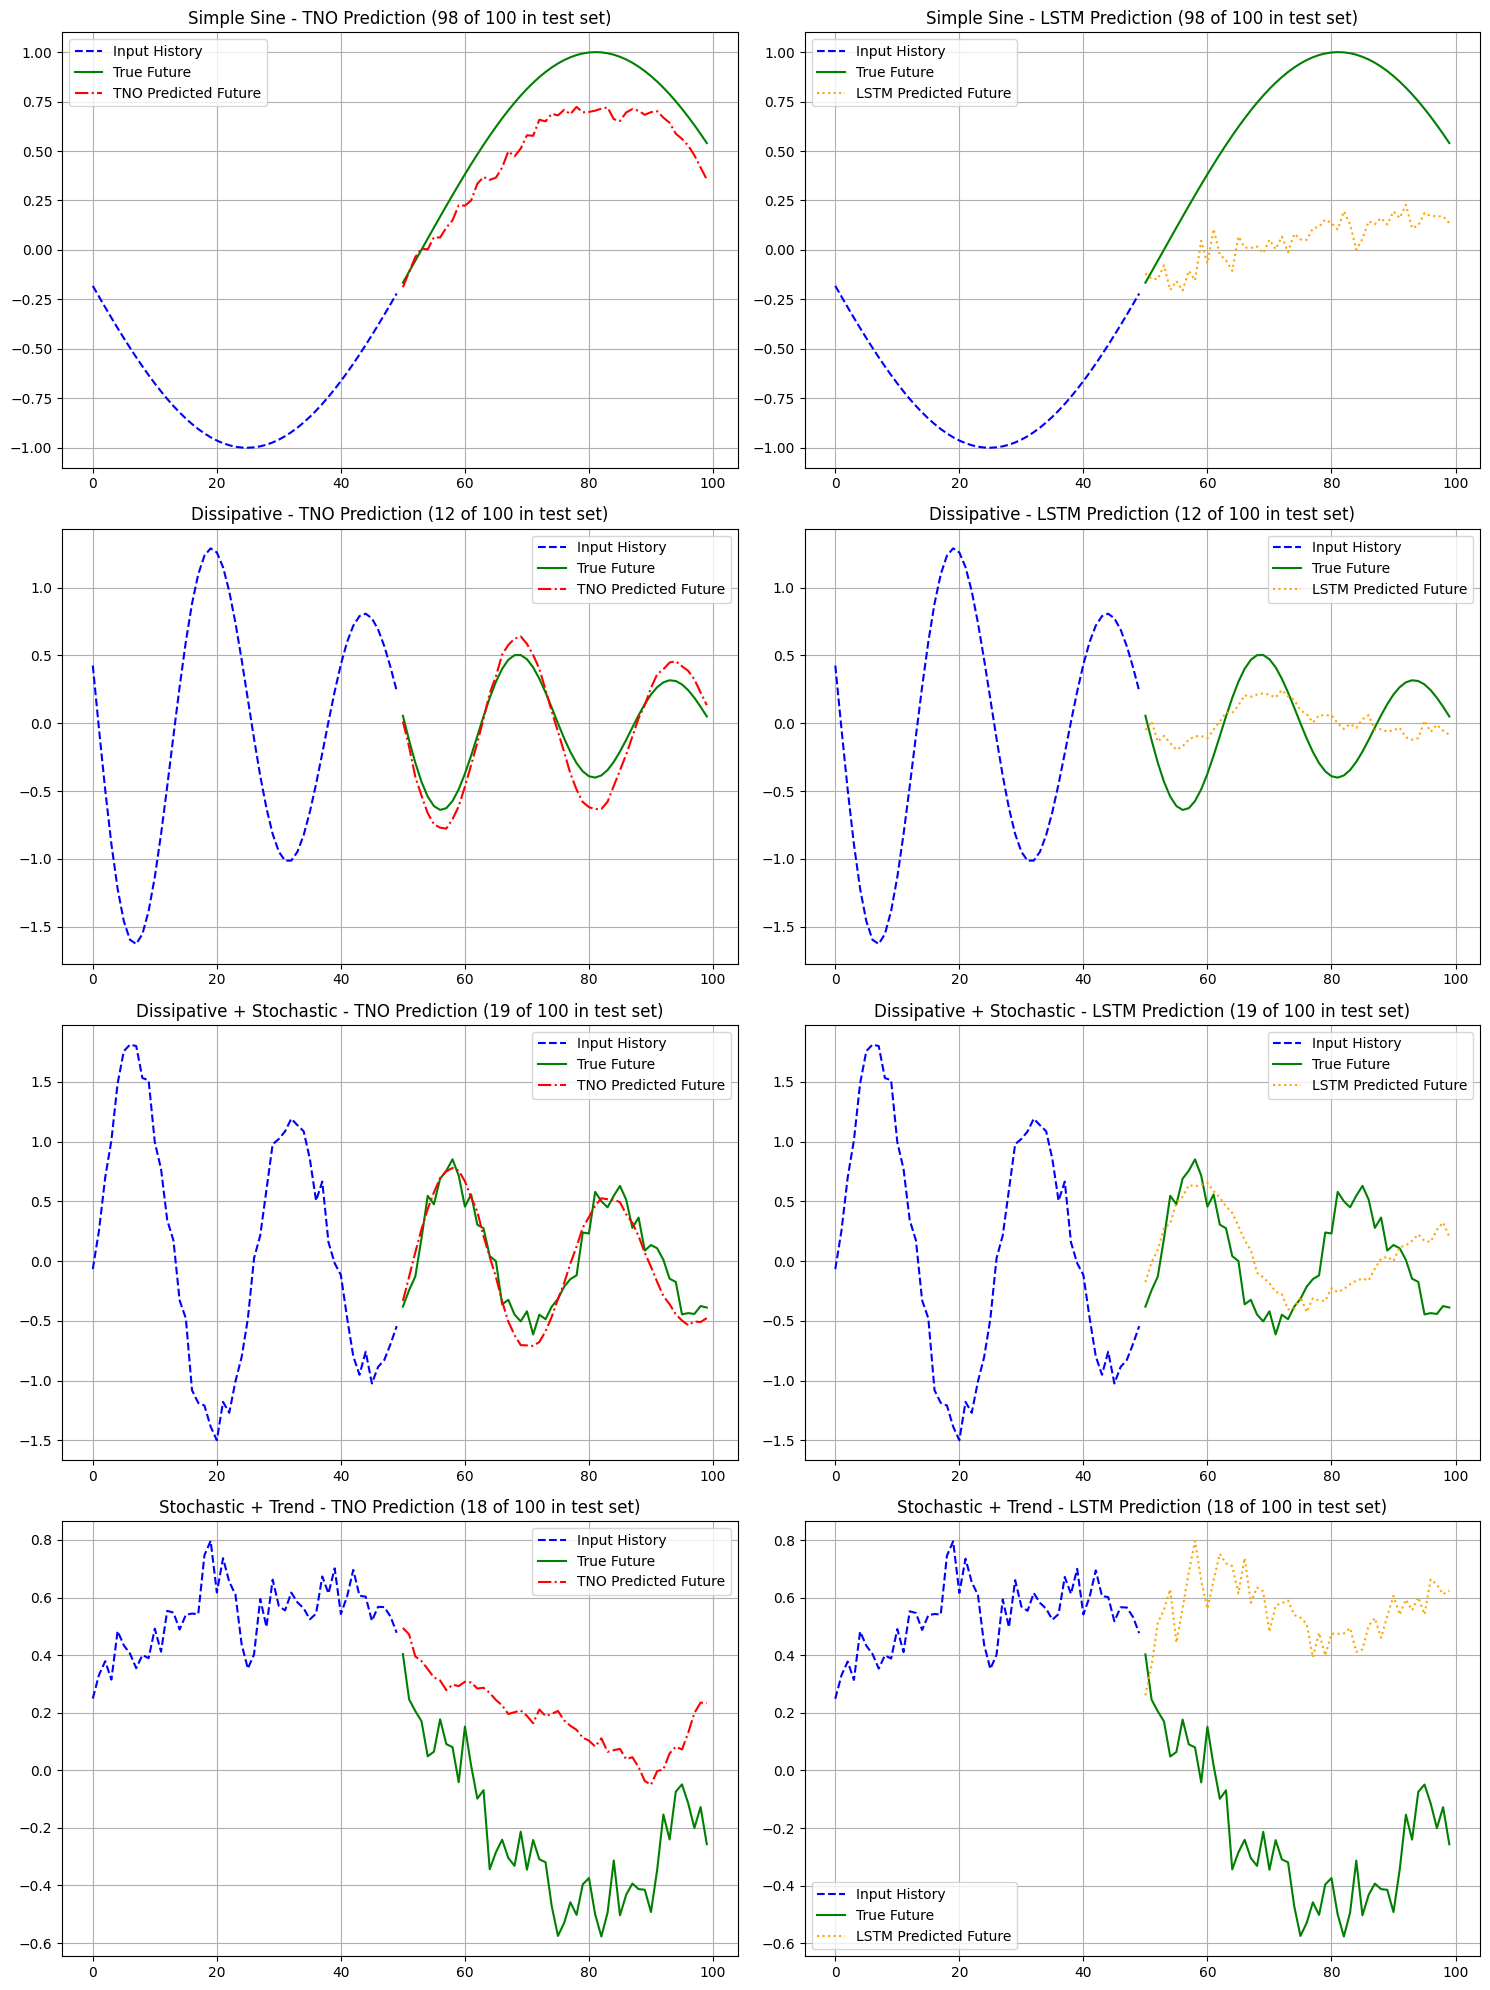

--- Comparison Plotting Complete ---


In [3]:

# --- 7. LSTM Model Definition ---
class LSTMModel(nn.Module):
    """A standard LSTM model for sequence-to-sequence prediction."""
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=20):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        # LSTM layer
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        # Output layer to map LSTM output to desired sequence length
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: (batch, seq_len_history, input_features=1)
        # Initialize hidden state and cell state
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0, c0))  # out: (batch, seq_len_history, hidden_size)

        # Take the last output from LSTM sequence
        last_output = out[:, -1, :] # (batch, hidden_size)

        # Pass through the final linear layer
        output = self.fc(last_output) # (batch, output_size)

        return output

print("\n--- Defining LSTM Model ---")
lstm_model = LSTMModel(input_size=1, hidden_size=64, num_layers=2, output_size=Y_train_tensor.shape[1]).to(device)
lstm_criterion = nn.MSELoss()
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001)
print("--- LSTM Model Defined ---")

# --- 8. LSTM Training Loop ---
print("--- Starting LSTM Training ---")
num_lstm_epochs = 200 # Same number of epochs as TNO for fair comparison
for epoch in range(num_lstm_epochs):
    lstm_model.train()
    lstm_optimizer.zero_grad()

    lstm_outputs = lstm_model(X_train_tensor.to(device))
    lstm_loss = lstm_criterion(lstm_outputs, Y_train_tensor.to(device).squeeze(-1)) # Remove channel dim for loss

    lstm_loss.backward()
    lstm_optimizer.step()

    if (epoch+1) % 50 == 0:
        print(f'LSTM Epoch [{epoch+1}/{num_lstm_epochs}], Loss: {lstm_loss.item():.6f}')

print("--- LSTM Training Complete ---")

# --- 9. LSTM Evaluation ---
print("--- Evaluating LSTM Model ---")
lstm_model.eval()
with torch.no_grad():
    lstm_test_outputs = lstm_model(X_test_tensor.to(device))
    lstm_test_loss = lstm_criterion(lstm_test_outputs, Y_test_tensor.to(device).squeeze(-1))
    # Inverse transform predictions and targets for interpretable metrics
    lstm_test_outputs_np = scaler_Y.inverse_transform(lstm_test_outputs.cpu().numpy().reshape(-1, 1)).reshape(lstm_test_outputs.shape) # Reshape for scaler
    # Y_test_tensor_np is already calculated from TNO evaluation, reuse it

    lstm_mse = mean_squared_error(Y_test_tensor_np.flatten(), lstm_test_outputs_np.flatten()) # Flatten for overall metrics
    lstm_mae = mean_absolute_error(Y_test_tensor_np.flatten(), lstm_test_outputs_np.flatten())

print(f'LSTM Test MSE: {lstm_mse:.6f}')
print(f'LSTM Test MAE: {lstm_mae:.6f}')
print("--- LSTM Evaluation Complete ---")

# --- 10. TNO Re-Evaluation (to get its test outputs again for comparison plotting) ---
print("--- Re-Evaluating TNO for Comparison Plotting ---")
model.eval() # Ensure TNO is in eval mode
with torch.no_grad():
    tno_test_outputs = model(X_test_tensor.to(device))
    # Inverse transform TNO predictions for plotting consistency
    tno_test_outputs_np = scaler_Y.inverse_transform(tno_test_outputs.cpu().numpy().reshape(-1, 1)).reshape(tno_test_outputs.shape)

print("--- TNO Re-Evaluation Complete ---")

# --- 11. Accuracy Comparison ---
print("\n--- Model Accuracy Comparison ---")
print(f"TNO Test MSE: {mse:.6f}")
print(f"LSTM Test MSE: {lstm_mse:.6f}")
print(f"TNO Test MAE: {mae:.6f}")
print(f"LSTM Test MAE: {lstm_mae:.6f}")

if mse < lstm_mse:
    print(f"\nTNO achieved lower MSE ({mse:.6f} vs {lstm_mse:.6f}).")
else:
    print(f"\nLSTM achieved lower MSE ({lstm_mse:.6f} vs {mse:.6f}).")

if mae < lstm_mae:
    print(f"TNO achieved lower MAE ({mae:.6f} vs {lstm_mae:.6f}).")
else:
    print(f"LSTM achieved lower MAE ({lstm_mae:.6f} vs {mae:.6f}).")
print("--- Comparison Complete ---")

# --- 12. Visualization: Compare TNO vs LSTM Predictions ---
print("--- Plotting TNO vs LSTM Predictions ---")
fig, axes = plt.subplots(4, 2, figsize=(15, 20)) # 4 rows for 4 sample types, 2 cols for TNO vs LSTM
sample_types = ["Simple Sine", "Dissipative", "Dissipative + Stochastic", "Stochastic + Trend"]

# Calculate the indices for each type within the TEST set (X_test_raw, Y_test_raw)
# Each type contributed 500 samples initially, with 80% train, 20% test.
# So, each type contributes 0.2 * 500 = 100 samples to the test set.
type_counts_per_split = [int(0.2 * 500), int(0.2 * 500), int(0.2 * 500), int(0.2 * 500)] # Should be [100, 100, 100, 100]
type_starts_test = [0] + list(np.cumsum(type_counts_per_split)[:-1]) # [0, 100, 200, 300]
type_ends_test = list(np.cumsum(type_counts_per_split))             # [100, 200, 300, 400]

for i, (title, start_idx, end_idx) in enumerate(zip(sample_types, type_starts_test, type_ends_test)):
    # Pick a random sample index *within* the current type's range in the TEST SET
    sample_idx_within_type_range = np.random.randint(0, end_idx - start_idx)
    sample_idx_global_in_test = start_idx + sample_idx_within_type_range

    # Get the data for the chosen sample from the test tensors
    x_sample_tensor = X_test_tensor[sample_idx_global_in_test:sample_idx_global_in_test+1] # Shape: (1, seq_len, 1)
    y_true_sample = Y_test_tensor_np[sample_idx_global_in_test]
    y_pred_tno_sample = tno_test_outputs_np[sample_idx_global_in_test]
    y_pred_lstm_sample = lstm_test_outputs_np[sample_idx_global_in_test]

    # Inverse transform the input sample for plotting
    x_plot = scaler_X.inverse_transform(x_sample_tensor.cpu().numpy().reshape(-1, 1)).reshape(x_sample_tensor.shape).ravel()

    # Plot TNO prediction
    ax_tno = axes[i, 0]
    ax_tno.plot(range(len(x_plot)), x_plot, label='Input History', linestyle='--', color='blue')
    ax_tno.plot(range(len(x_plot), len(x_plot) + len(y_true_sample)), y_true_sample, label='True Future', color='green')
    ax_tno.plot(range(len(x_plot), len(x_plot) + len(y_pred_tno_sample)), y_pred_tno_sample, label='TNO Predicted Future', color='red', linestyle='-.')
    ax_tno.set_title(f'{title} - TNO Prediction ({sample_idx_within_type_range+1} of {end_idx-start_idx} in test set)')
    ax_tno.legend()
    ax_tno.grid(True)

    # Plot LSTM prediction
    ax_lstm = axes[i, 1]
    ax_lstm.plot(range(len(x_plot)), x_plot, label='Input History', linestyle='--', color='blue')
    ax_lstm.plot(range(len(x_plot), len(x_plot) + len(y_true_sample)), y_true_sample, label='True Future', color='green')
    ax_lstm.plot(range(len(x_plot), len(x_plot) + len(y_pred_lstm_sample)), y_pred_lstm_sample, label='LSTM Predicted Future', color='orange', linestyle=':')
    ax_lstm.set_title(f'{title} - LSTM Prediction ({sample_idx_within_type_range+1} of {end_idx-start_idx} in test set)')
    ax_lstm.legend()
    ax_lstm.grid(True)

plt.tight_layout()
plt.show()
print("--- Comparison Plotting Complete ---")